# 01 · Exploratory Data Analysis — Credit Card Fraud

**Phase 0, Step 8.** This notebook is *exploration only*. Its purpose is to build
understanding of the dataset so that Phase 1 (`src/data/*.py`) can be written with
informed decisions. **No function, class, or logic defined here is production code** —
nothing is imported from `src/`, nothing is written to `src/`, and none of this is
ported literally later.

Dataset: `data/raw/creditcard.csv` (Kaggle `mlg-ulb/creditcardfraud`). Features `V1`–`V28`
are anonymized **PCA components**; only `Time`, `Amount`, and the `Class` target are
directly interpretable.

The single most important question of the whole EDA is **class imbalance** — it dictates
the metric (PR-AUC over ROC-AUC), the imbalance-handling strategy, and the decision
threshold in later phases.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Notebook lives in notebooks/; data is one level up under data/raw/.
df = pd.read_csv("../data/raw/creditcard.csv")
df.shape

(284807, 31)

## 1. Shape and structure

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**Observations — structure.** 284,807 transactions × 31 columns. Every column is
numeric (`float64`, with `Class` as `int64`), so no categorical encoding is needed. The
`V1`–`V28` columns are already standardized PCA outputs (mean ~0); `Time` and `Amount`
live on very different scales and will need scaling before any distance/gradient-based
model.

## 2. Data quality

In [5]:
nulls = df.isnull().sum()
print("Total null values:", int(nulls.sum()))
nulls[nulls > 0]

Total null values: 0


Series([], dtype: int64)

In [6]:
n_dupes = df.duplicated().sum()
print("Exact duplicate rows:", int(n_dupes))
print("Duplicates by Class:")
df[df.duplicated()]["Class"].value_counts()

Exact duplicate rows: 1081
Duplicates by Class:


Class
0    1062
1      19
Name: count, dtype: int64

**Observations — quality.** No missing values anywhere. There are **1,081 exact
duplicate rows** (1,062 legitimate, 19 fraud). Because features are anonymized PCA
components, identical rows almost certainly represent the same underlying transaction
recorded twice rather than a genuine coincidence — a candidate for de-duplication in
Phase 1, though the 19 fraud duplicates must be handled carefully given how scarce the
positive class is.

## 3. Class imbalance — THE MOST IMPORTANT QUESTION

In [7]:
counts = df["Class"].value_counts()
props = df["Class"].value_counts(normalize=True)
print("Counts:")
print(counts)
print("\nProportions:")
print(props)
fraud_rate = props.get(1, 0) * 100
ratio = counts.get(0, 0) / counts.get(1, 1)
print(f"\nFraud rate: {fraud_rate:.6f}%  (1 fraud per ~{ratio:.0f} legitimate)")

Counts:
Class
0    284315
1       492
Name: count, dtype: int64

Proportions:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Fraud rate: 0.172749%  (1 fraud per ~578 legitimate)


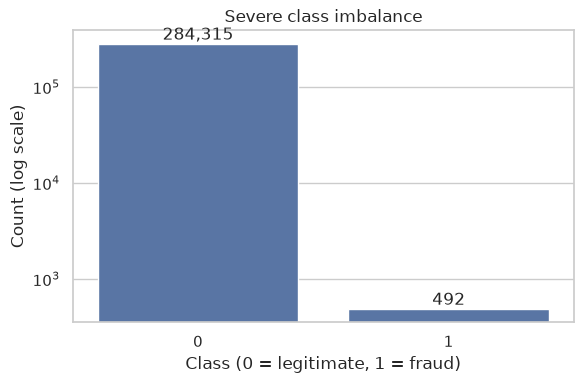

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Class (0 = legitimate, 1 = fraud)")
ax.set_ylabel("Count (log scale)")
ax.set_title("Severe class imbalance")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Observations — imbalance.** The positive class is **0.173%** of the data
(492 frauds in 284,807 transactions, ~1:578). This is the defining property of the
problem and drives three downstream decisions: **(1) metric** — accuracy is useless
(predicting "all legitimate" scores 99.83%); we report **PR-AUC** and prioritize
**recall**. **(2) imbalance handling** — class weights / resampling (e.g. SMOTE) are
required in Phase 2. **(3) threshold** — the 0.5 default is meaningless; the decision
threshold must be tuned to the business cost trade-off and versioned with the model.

## 4. Distribution of interpretable features per class — `Amount`

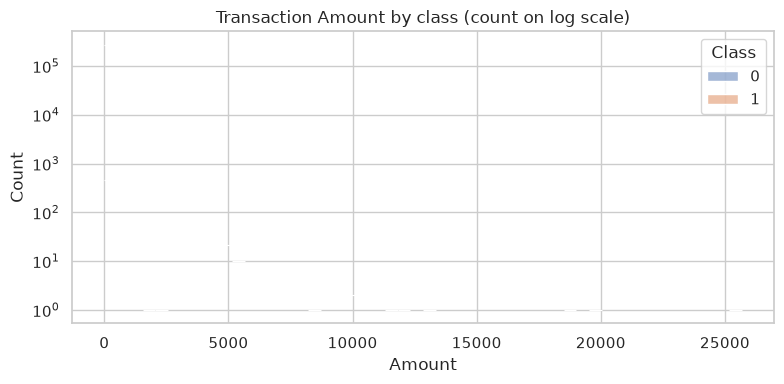

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df, x="Amount", hue="Class", bins=50, log_scale=(False, True), ax=ax)
ax.set_title("Transaction Amount by class (count on log scale)")
plt.tight_layout()
plt.show()

In [10]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [11]:
zero_amount = (df["Amount"] == 0).mean() * 100
print(f"Transactions with Amount == 0: {zero_amount:.3f}%")

Transactions with Amount == 0: 0.641%


**Observations — `Amount`.** Fraudulent transactions have a **higher mean** amount
(€122.21 vs €88.29) but a **lower median** (€9.25 vs €22.00) — fraud skews toward many
small-value transactions plus a few large ones, while its maximum (€2,125.87) is far
below the legitimate maximum (€25,691.16). `Amount` carries some signal but is not a
strong standalone separator. Its wide range and right skew argue for scaling (and
possibly a log transform) in preprocessing.

## 5. Temporal patterns — `Time`

In [12]:
# Time is seconds elapsed from the first transaction; the dataset spans ~48h.
print(
    "Max Time (s):",
    int(df["Time"].max()),
    "->",
    round(df["Time"].max() / 3600, 1),
    "hours",
)
df = df.assign(Hour=(df["Time"] // 3600) % 24)

Max Time (s): 172792 -> 48.0 hours


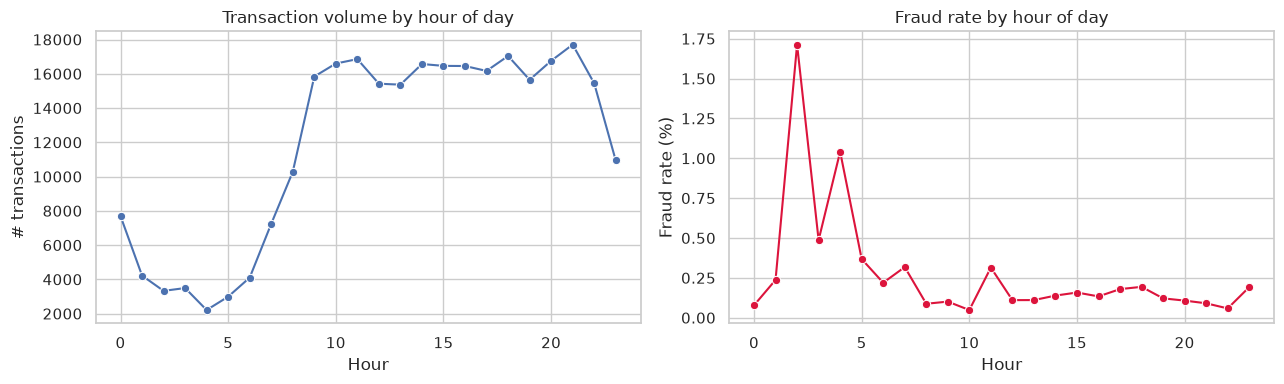

,n_tx,fraud_rate_pct
Hour,,
0.0,7695,0.077973
1.0,4220,0.236967
2.0,3328,1.712740
3.0,3492,0.486827
4.0,2209,1.041195
5.0,2990,0.367893
6.0,4101,0.219459
7.0,7243,0.317548
8.0,10276,0.087583


In [13]:
hourly = df.groupby("Hour").agg(
    n_tx=("Class", "size"),
    fraud_rate_pct=("Class", lambda s: s.mean() * 100),
)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.lineplot(x=hourly.index, y=hourly["n_tx"], marker="o", ax=axes[0])
axes[0].set_title("Transaction volume by hour of day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("# transactions")
sns.lineplot(
    x=hourly.index, y=hourly["fraud_rate_pct"], marker="o", color="crimson", ax=axes[1]
)
axes[1].set_title("Fraud rate by hour of day")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Fraud rate (%)")
plt.tight_layout()
plt.show()
hourly

**Observations — `Time`.** Legitimate volume follows a clear day/night cycle
(peaks in daytime hours, troughs overnight). The **fraud rate moves opposite to volume**:
it is highest in the low-traffic small hours (peaking ~1.7% around 02:00) and lowest
during the busy mid-morning (~0.05% around 10:00). Absolute `Time` is not reusable at
serving time (it is relative to this capture window), but a **cyclical hour-of-day
feature** derived from a request timestamp could be engineered in Phase 1.

## 6. Correlations

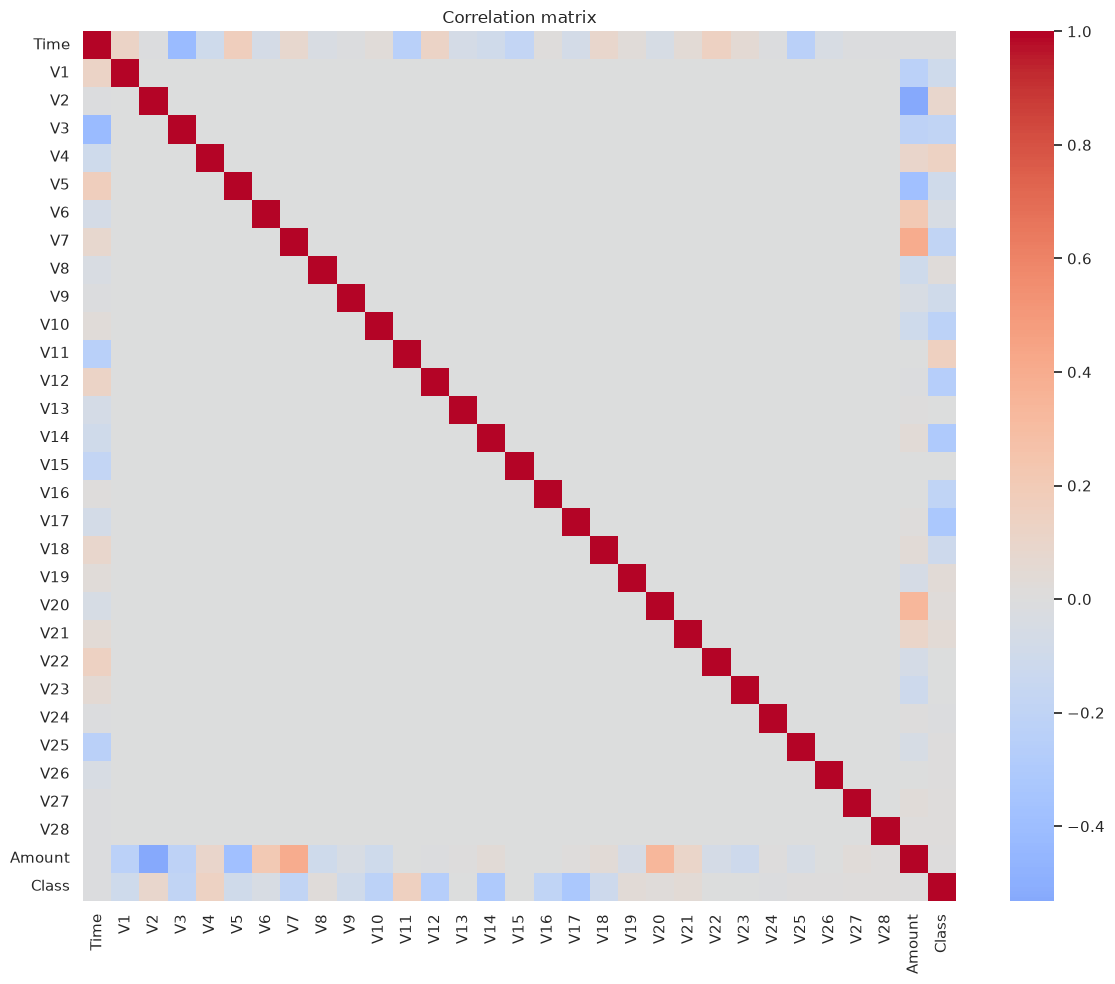

In [14]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.drop(columns="Hour").corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

In [15]:
# Point-biserial correlation of each feature with the target.
corr_with_class = (
    df.drop(columns="Hour")
    .corr(numeric_only=True)["Class"]
    .drop("Class")
    .abs()
    .sort_values(ascending=False)
)
corr_with_class.head(12)

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
V1     0.101347
V9     0.097733
Name: Class, dtype: float64

**Observations — correlations.** As expected from PCA, the `V` components are
mutually near-uncorrelated (clean diagonal). The strongest linear associations with the
target are **V17, V14, V12, V10, V16, V11** (|corr| ≈ 0.20–0.33). `Amount` and `Time`
show only weak linear correlation with `Class`, consistent with Sections 4–5. No single
feature separates the classes alone — the signal is distributed, which is why a
multivariate model is warranted.

## 7. Full sweep of the PCA components `V1`–`V28`

Per the chosen *full-exploration* depth: rank all 28 components by discriminative power,
inspect the distributions of the strongest ones by class, and view the overall dispersion
of every component across classes. These are anonymized so interpretation stops at
"discriminative or not" — no feature-name semantics are available.

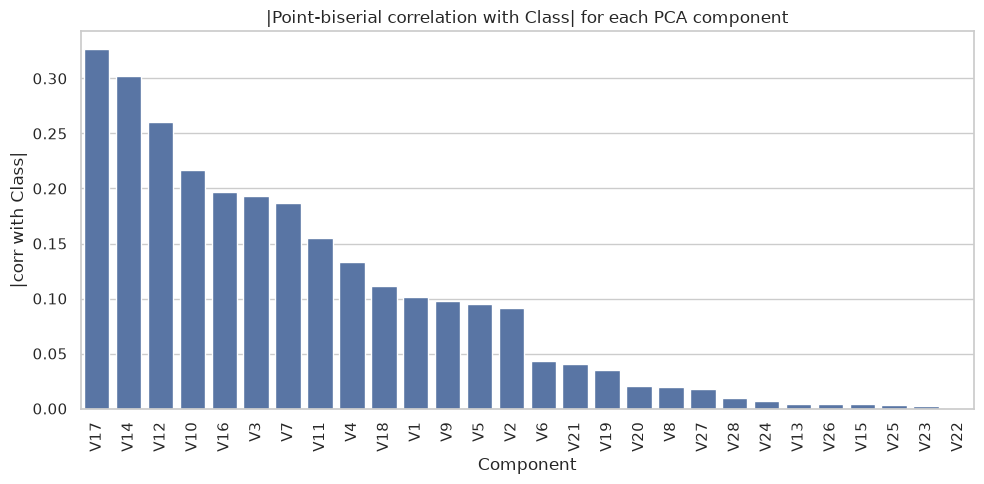

In [16]:
v_cols = [f"V{i}" for i in range(1, 29)]
v_corr = corr_with_class.reindex(v_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=v_corr.index, y=v_corr.values, ax=ax)
ax.set_title("|Point-biserial correlation with Class| for each PCA component")
ax.set_xlabel("Component")
ax.set_ylabel("|corr with Class|")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

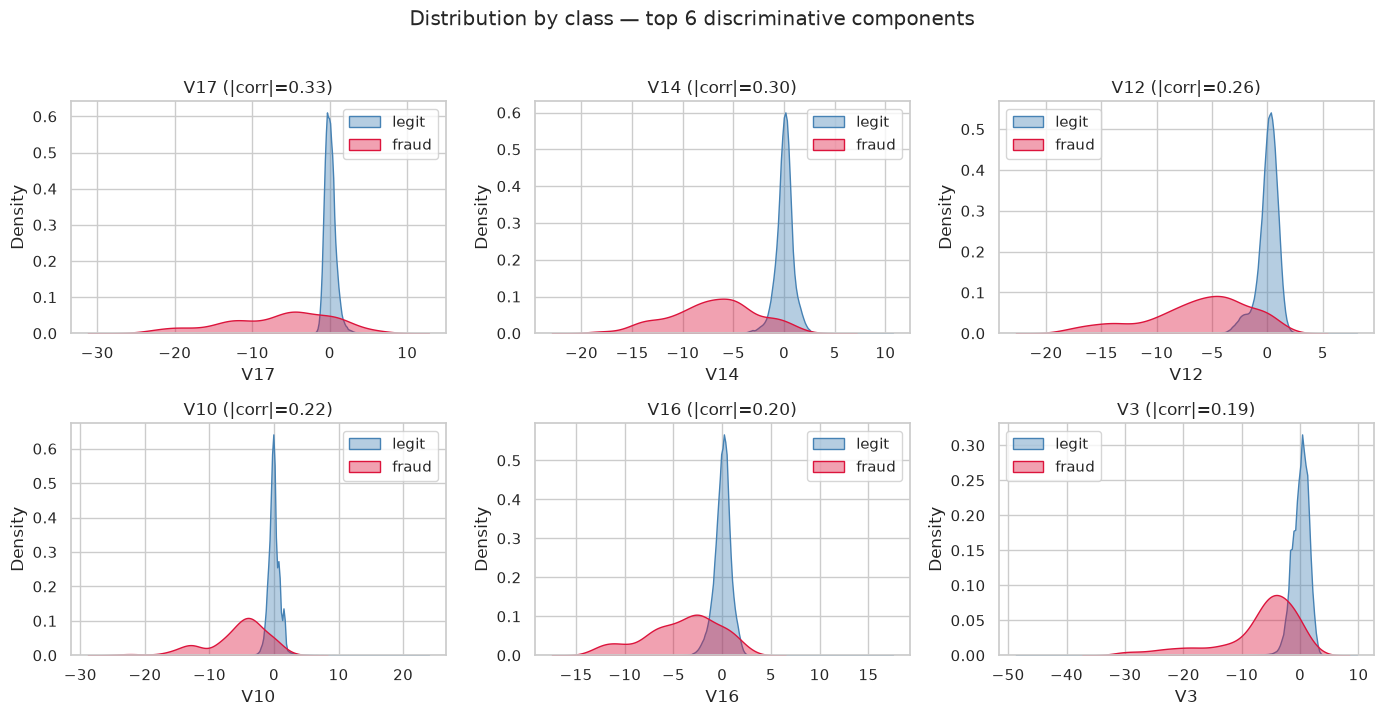

In [17]:
# Distributions by class for the 6 most discriminative components.
top6 = v_corr.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), top6):
    for cls, color in [(0, "steelblue"), (1, "crimson")]:
        sns.kdeplot(
            df.loc[df["Class"] == cls, col],
            ax=ax,
            fill=True,
            alpha=0.4,
            color=color,
            label=("legit" if cls == 0 else "fraud"),
            common_norm=False,
        )
    ax.set_title(f"{col} (|corr|={v_corr[col]:.2f})")
    ax.legend()
fig.suptitle("Distribution by class — top 6 discriminative components", y=1.02)
plt.tight_layout()
plt.show()

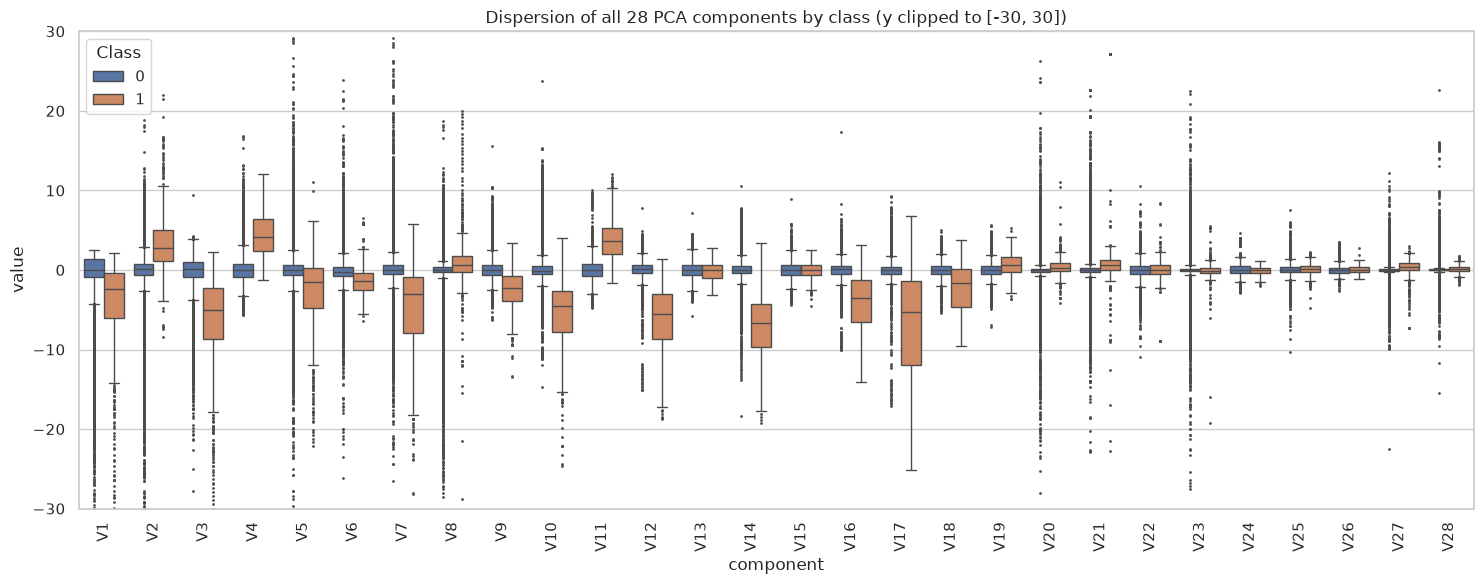

In [18]:
# Dispersion of ALL 28 components by class (standardized), to spot outlier structure.
melted = df.melt(
    id_vars="Class", value_vars=v_cols, var_name="component", value_name="value"
)
fig, ax = plt.subplots(figsize=(15, 6))
sns.boxplot(data=melted, x="component", y="value", hue="Class", fliersize=1, ax=ax)
ax.set_ylim(-30, 30)
ax.set_title("Dispersion of all 28 PCA components by class (y clipped to [-30, 30])")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Observations — PCA sweep.** Discriminative power is concentrated in a handful of
components (V17, V14, V12, V10, V16, V11, V3, V7); the remainder barely separate the
classes. For the strongest components the fraud distribution is clearly **shifted and
heavier-tailed** relative to legitimate transactions (visible in both the KDEs and the
boxplots). This confirms that a subset of the anonymized components carries most of the
signal — useful to know, but since they are PCA outputs we cannot do interpretable
feature engineering on them; they are consumed as-is.

## Summary of Findings

*All figures below come from the executed cells above, in this run.*

| Question | Finding |
|---|---|
| **Shape** | 284,807 transactions × 31 columns, all numeric |
| **Missing values** | None (0) |
| **Duplicates** | 1,081 exact duplicate rows (1,062 legit / 19 fraud) |
| **Class imbalance** | **492 frauds → fraud rate = 0.172749%** (≈ 1 : 578) — the defining property |
| **`Amount`** | Fraud has higher mean (122.21 vs 88.29) but lower median (9.25 vs 22.00); weak standalone separator |
| **`Time`** | ~48h span; fraud rate anti-correlates with volume (peak ~1.7% at night, ~0.05% mid-morning) |
| **Discriminative features** | V17, V14, V12, V10, V16, V11 (|corr| ≈ 0.20–0.33); signal distributed, no single separator |

**What this anticipates for Phase 1 / Phase 2:**

1. **Metric & imbalance** — report **PR-AUC** and prioritize **recall**; accuracy and
   ROC-AUC are misleading at 0.17% prevalence. Handle imbalance explicitly (class weights
   / SMOTE) and **tune + version the decision threshold** with the model.
2. **Scaling** — scale `Amount` (and `Time`-derived features); the `V` components are
   already standardized.
3. **Duplicates** — decide a de-duplication policy in the DVC pipeline, treating the 19
   fraud duplicates with care given class scarcity.
4. **Feature engineering** — `Time` is capture-relative and not directly reusable at
   serving; a cyclical hour-of-day feature is the interpretable option. The `V`
   components are anonymized PCA outputs and are consumed as-is (a documented dataset
   limitation, not a modelling failure).
5. **Training–serving skew** — all preprocessing (scaling, any derived features) must be
   packaged *with* the model as one artifact so the API feeds raw input straight in.